# Embodied AI Lab — Reachy Mini Prompt Analysis
### Cosine Similarity & Outcome Profiling · TF-IDF Embeddings
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'savefig.facecolor': 'white',
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'font.family':       'DejaVu Sans',
    'font.size':         16,
    'axes.titlesize':    22,
    'axes.titleweight':  'bold',
    'axes.labelsize':    17,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'legend.fontsize':   14,
    'legend.framealpha': 0.9,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         False,
})

C     = {'success': '#1B6CA8', 'partial': '#E07B00', 'failure': '#C0392B'}
LIGHT = {'success': '#D6EAF8', 'partial': '#FDEBD0', 'failure': '#FADBD8'}
print("Environment ready.")


Environment ready.


In [2]:
# All data embedded — no external files needed
rows = [
    (1, "can you spin",                        "success", "head moved / rotated"),
    (1, "can you rotate in a circle",          "success", "head rotated"),
    (1, "can you spin your head",              "failure", "could not do it"),
    (1, "can you jump",                        "failure", "no jump"),
    (1, "can you do a head dive",              "success", "it danced"),
    (1, "can you dance",                       "success", "moved head back and forth"),
    (1, "can you dance",                       "success", "moved head in circle"),
    (1, "can you dance",                       "success", "head bobble"),
    (1, "asked to dance",                      "success", "wiggled neck body"),
    (1, "asked to dance",                      "success", "shaked antenna"),
    (1, "asked to dance",                      "partial", "switched motion"),
    (2, "can you hop",                         "success", "rotated moved head"),
    (2, "can you jump",                        "failure", "no movement"),
    (2, "i cannot do that",                    "failure", "no movement"),
    (2, "i cannot do that",                    "failure", "no movement different voice"),
    (2, "sure i will dance",                   "success", "robot danced"),
    (2, "can you break dance",                 "success", "sway and roll"),
    (2, "can you dance like a rock star",      "success", "nods its head"),
    (2, "can you dance like michael jackson",  "success", "shifts side to side"),
    (3, "stand still then dance",              "partial", "did not stay still then danced"),
    (3, "explain quantum physics",             "failure", "refusal"),
    (3, "dance but stand still",               "partial", "robot stayed still"),
    (3, "be a cat and dance",                  "failure", "no action"),
    (3, "do the worm backflip",                "partial", "unexpected motion"),
    (3, "can you do a backflip",               "failure", "no motion"),
    (3, "can you do the whip nae nae",         "failure", "no motion"),
]

df = pd.DataFrame(rows, columns=['round', 'prompt', 'outcome', 'robot_response'])
df['prompt_id']    = range(len(df))



In [3]:
df['outcome'].value_counts()

outcome
success    13
failure     9
partial     4
Name: count, dtype: int64

In [4]:
df.head()

,round,prompt,outcome,robot_response,prompt_id
0,1,can you spin,success,head moved / rotated,0
1,1,can you rotate in a circle,success,head rotated,1
2,1,can you spin your head,failure,could not do it,2
3,1,can you jump,failure,no jump,3
4,1,can you do a head dive,success,it danced,4


In [5]:
df['prompt_short'] = df['prompt'].str[:28]

vectorizer  = TfidfVectorizer(stop_words=None, ngram_range=(1,1))
tfidf_mat   = vectorizer.fit_transform(df['prompt'])
sim_matrix  = cosine_similarity(tfidf_mat)

def centroid_sim(pid, outcome):
    targets = df[(df['outcome'] == outcome) & (df['prompt_id'] != pid)]['prompt_id'].values
    return sim_matrix[pid, targets].mean() if len(targets) else 0.0

df['sim_to_success'] = df['prompt_id'].apply(lambda x: centroid_sim(x, 'success'))
df['sim_to_failure'] = df['prompt_id'].apply(lambda x: centroid_sim(x, 'failure'))
df['sim_to_partial'] = df['prompt_id'].apply(lambda x: centroid_sim(x, 'partial'))
df['delta']          = df['sim_to_success'] - df['sim_to_failure']

print(df[['round','prompt_short','outcome','sim_to_success','sim_to_failure','delta']].to_string(index=False))

 round                 prompt_short outcome  sim_to_success  sim_to_failure     delta
     1                 can you spin success        0.219811        0.182919  0.036892
     1   can you rotate in a circle success        0.134691        0.078938  0.055754
     1       can you spin your head failure        0.196920        0.079781  0.117140
     1                 can you jump failure        0.226920        0.199006  0.027914
     1       can you do a head dive success        0.152485        0.198808 -0.046323
     1                can you dance success        0.456136        0.209131  0.247005
     1                can you dance success        0.456136        0.209131  0.247005
     1                can you dance success        0.456136        0.209131  0.247005
     1               asked to dance success        0.176938        0.010650  0.166288
     1               asked to dance success        0.176938        0.010650  0.166288
     1               asked to dance partial        0.2

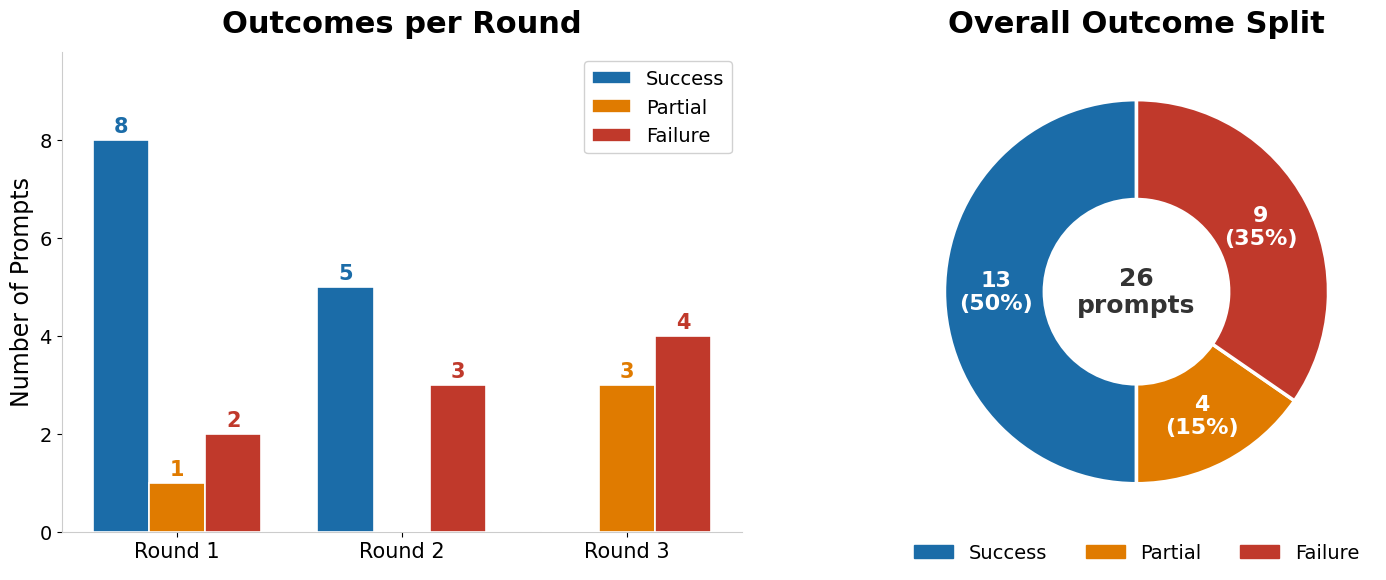

Saved plot1_outcome_distribution.png


In [6]:
# PLOT 1 — Outcome Distribution
counts = df.groupby(['round', 'outcome']).size().unstack(fill_value=0)
for col in ['success', 'partial', 'failure']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[['success', 'partial', 'failure']]
total_counts = df['outcome'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

# Grouped bars
ax = axes[0]
x  = np.arange(len(counts))
w  = 0.25
labels   = ['Success', 'Partial', 'Failure']
outcomes = ['success', 'partial', 'failure']
for i, (o, lbl) in enumerate(zip(outcomes, labels)):
    vals = counts[o].values
    bars = ax.bar(x + i*w, vals, width=w, color=C[o], label=lbl,
                  edgecolor='white', linewidth=1.2, zorder=3)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                    str(int(v)), ha='center', va='bottom', fontsize=15, fontweight='bold',
                    color=C[o])

ax.set_xticks(x + w)
ax.set_xticklabels([f'Round {r}' for r in counts.index], fontsize=15)
ax.set_ylabel('Number of Prompts', fontsize=17)
ax.set_title('Outcomes per Round', fontsize=22, fontweight='bold', pad=14)
ax.set_ylim(0, counts.values.max() + 1.8)
ax.legend(loc='upper right', fontsize=14, frameon=True)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Donut
ax2   = axes[1]
sizes = [total_counts.get(o, 0) for o in outcomes]
colors = [C[o] for o in outcomes]
wedges, _ = ax2.pie(sizes, colors=colors, startangle=90,
                    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5))
for wedge, o, s in zip(wedges, outcomes, sizes):
    angle = (wedge.theta2 + wedge.theta1) / 2
    xp = 0.73 * np.cos(np.radians(angle))
    yp = 0.73 * np.sin(np.radians(angle))
    pct = 100 * s / sum(sizes)
    ax2.text(xp, yp, f'{int(s)}\n({pct:.0f}%)',
             ha='center', va='center', fontsize=16, fontweight='bold', color='white')
ax2.text(0, 0, f'{sum(sizes)}\nprompts',
         ha='center', va='center', fontsize=18, fontweight='bold', color='#333333')
ax2.set_title('Overall Outcome Split', fontsize=22, fontweight='bold', pad=14)
patches = [mpatches.Patch(color=C[o], label=l) for o, l in zip(outcomes, labels)]
ax2.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.10),
           ncol=3, fontsize=14, frameon=False)

plt.tight_layout(pad=3)
plt.savefig('plots/plot1_outcome_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot1_outcome_distribution.png")


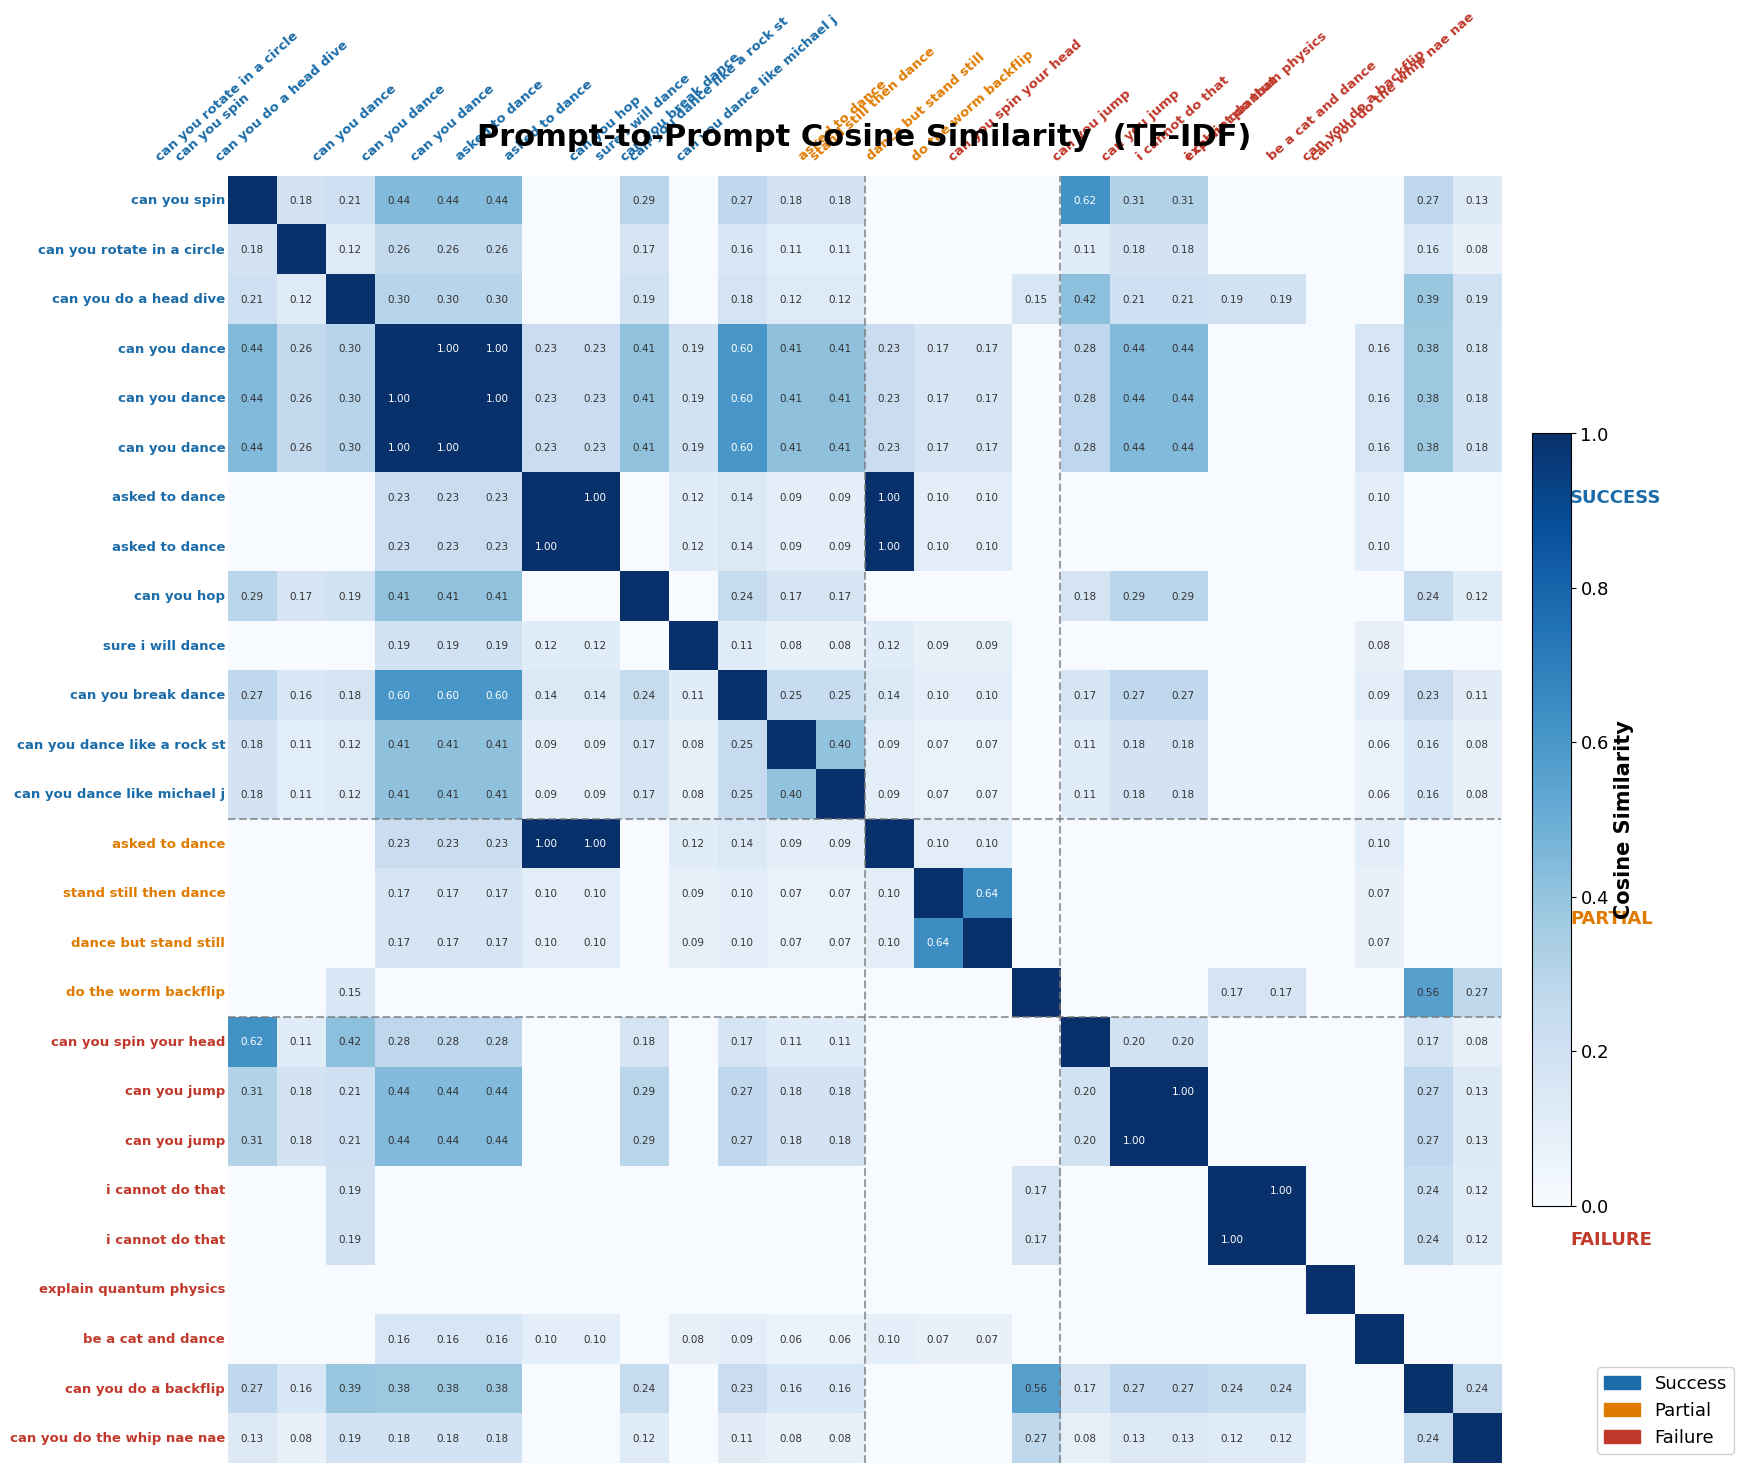

Saved plot2_similarity_heatmap.png


In [7]:
# PLOT 2 — Full Cosine Similarity Heatmap
outcomes_order = ['success', 'partial', 'failure']
order = []
for o in outcomes_order:
    order.extend(df[df['outcome']==o].sort_values('round')['prompt_id'].tolist())

labels_s   = df.set_index('prompt_id').loc[order, 'prompt_short'].tolist()
outcomes_s = df.set_index('prompt_id').loc[order, 'outcome'].tolist()
sim_ord    = sim_matrix[np.ix_(order, order)]
n          = len(order)

fig, ax = plt.subplots(figsize=(18, 15), facecolor='white')
im = ax.imshow(sim_ord, cmap='Blues', vmin=0, vmax=1, aspect='auto')

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
for i, (lbl, o) in enumerate(zip(labels_s, outcomes_s)):
    ax.text(-0.55, i, lbl, ha='right', va='center', fontsize=9.5,
            color=C[o], fontweight='bold', transform=ax.transData)
    ax.text(i, -0.75, lbl, ha='right', va='bottom', fontsize=9.5,
            color=C[o], fontweight='bold', rotation=42, transform=ax.transData)

for i in range(n):
    for j in range(n):
        val = sim_ord[i, j]
        if i != j and val > 0.06:
            tc = 'white' if val > 0.6 else '#333333'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5, color=tc)

cbar = plt.colorbar(im, ax=ax, shrink=0.60, pad=0.02)
cbar.set_label('Cosine Similarity', fontsize=15, fontweight='bold')
cbar.ax.tick_params(labelsize=13)

group_sizes = [len(df[df['outcome']==o]) for o in outcomes_order]
cumul = 0
for gs in group_sizes[:-1]:
    cumul += gs
    ax.axhline(cumul - 0.5, color='#777777', linewidth=1.5, linestyle='--', alpha=0.7)
    ax.axvline(cumul - 0.5, color='#777777', linewidth=1.5, linestyle='--', alpha=0.7)

pos = 0
for gs, gl in zip(group_sizes, ['SUCCESS','PARTIAL','FAILURE']):
    mid = pos + gs/2 - 0.5
    ax.text(n + 0.9, mid, gl, ha='left', va='center', fontsize=13,
            fontweight='bold', color=C[gl.lower()], transform=ax.transData)
    pos += gs

ax.set_title('Prompt-to-Prompt Cosine Similarity  (TF-IDF)', fontsize=22,
             fontweight='bold', pad=22)
patches = [mpatches.Patch(color=C[o], label=o.title()) for o in ['success','partial','failure']]
ax.legend(handles=patches, loc='lower right', fontsize=13, frameon=True,
          bbox_to_anchor=(1.19, 0))

plt.tight_layout()
plt.savefig('plots/plot2_similarity_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot2_similarity_heatmap.png")


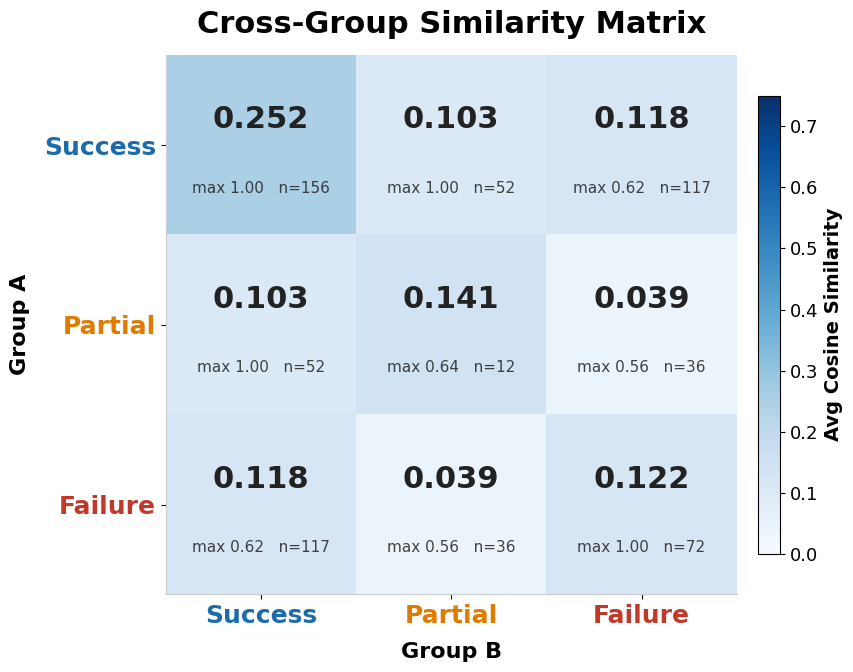

Saved plot3_group_similarity.png


In [8]:
# PLOT 3 — Group Cross-Similarity 3x3 Matrix
outcomes = ['success', 'partial', 'failure']
group_avg = np.zeros((3,3))
group_max = np.zeros((3,3))
group_n   = np.zeros((3,3), dtype=int)

for ri, o1 in enumerate(outcomes):
    for ci, o2 in enumerate(outcomes):
        idx_a = df[df['outcome']==o1]['prompt_id'].values
        idx_b = df[df['outcome']==o2]['prompt_id'].values
        vals  = [sim_matrix[a, b] for a in idx_a for b in idx_b if a != b]
        group_avg[ri, ci] = np.mean(vals) if vals else 0
        group_max[ri, ci] = np.max(vals)  if vals else 0
        group_n[ri, ci]   = len(vals)

fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
im = ax.imshow(group_avg, cmap='Blues', vmin=0, vmax=0.75, aspect='auto')
tick_labels = ['Success', 'Partial', 'Failure']
ax.set_xticks(range(3)); ax.set_xticklabels(tick_labels, fontsize=18, fontweight='bold')
ax.set_yticks(range(3)); ax.set_yticklabels(tick_labels, fontsize=18, fontweight='bold')
for tl, o in zip(ax.get_xticklabels(), outcomes): tl.set_color(C[o])
for tl, o in zip(ax.get_yticklabels(), outcomes): tl.set_color(C[o])

for ri in range(3):
    for ci in range(3):
        avg_v = group_avg[ri, ci]
        max_v = group_max[ri, ci]
        tc    = 'white' if avg_v > 0.42 else '#222222'
        ax.text(ci, ri - 0.14, f'{avg_v:.3f}',
                ha='center', va='center', fontsize=22, fontweight='bold', color=tc)
        ax.text(ci, ri + 0.24, f'max {max_v:.2f}   n={group_n[ri,ci]}',
                ha='center', va='center', fontsize=11, color=tc, alpha=0.85)

cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label('Avg Cosine Similarity', fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=13)
ax.set_xlabel('Group B', fontsize=16, fontweight='bold', labelpad=10)
ax.set_ylabel('Group A', fontsize=16, fontweight='bold', labelpad=10)
ax.set_title('Cross-Group Similarity Matrix', fontsize=22, fontweight='bold', pad=16)
for spine in ax.spines.values(): spine.set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('plots/plot3_group_similarity.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot3_group_similarity.png")


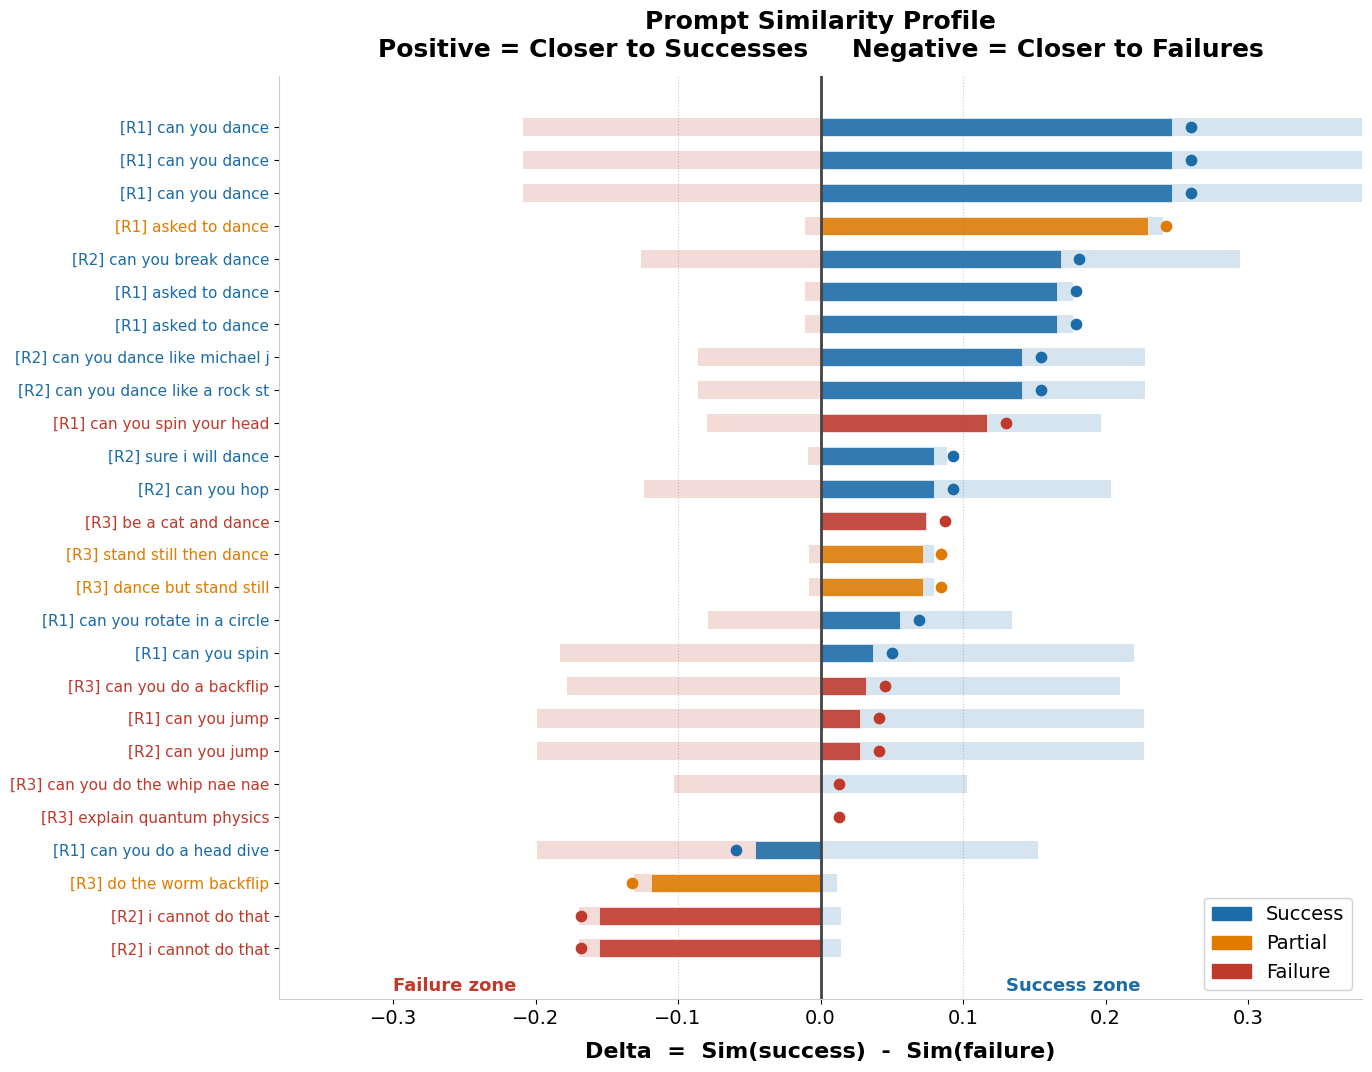

Saved plot4_delta_profile.png


In [9]:
# PLOT 4 — Per-Prompt Delta Profile
df_s = df.sort_values('delta').reset_index(drop=True)
n    = len(df_s)

fig, ax = plt.subplots(figsize=(14, 11), facecolor='white')

for i, row in df_s.iterrows():
    clr   = C[row['outcome']]
    delta = row['delta']
    ax.barh(i, row['sim_to_success'], height=0.55, color=C['success'], alpha=0.18, zorder=2)
    ax.barh(i, -row['sim_to_failure'], height=0.55, color=C['failure'], alpha=0.18, zorder=2)
    ax.barh(i, delta, height=0.55, color=clr, alpha=0.88, zorder=3,
            edgecolor='white', linewidth=0.5)
    ax.scatter(delta + (0.013 if delta >= 0 else -0.013), i, color=clr, s=55, zorder=5)

ax.axvline(0,    color='#444444', linewidth=2.0, zorder=4)
ax.axvline( 0.1, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=1)
ax.axvline(-0.1, color='#CCCCCC', linewidth=0.8, linestyle=':', zorder=1)

ax.set_yticks(range(n))
ax.set_yticklabels(
    [f'[R{r}] {p[:30]}' for r, p in zip(df_s['round'], df_s['prompt_short'])],
    fontsize=11)
for tick, o in zip(ax.get_yticklabels(), df_s['outcome']):
    tick.set_color(C[o])

ax.set_xlabel('Delta  =  Sim(success)  -  Sim(failure)', fontsize=16,
              fontweight='bold', labelpad=10)
title_line1 = 'Prompt Similarity Profile'
title_line2 = 'Positive = Closer to Successes     Negative = Closer to Failures'
ax.set_title(title_line1 + '\n' + title_line2, fontsize=18, fontweight='bold', pad=14)

ax.text(-0.30, -1.3, 'Failure zone', fontsize=13, color=C['failure'], fontweight='bold')
ax.text( 0.13, -1.3, 'Success zone', fontsize=13, color=C['success'], fontweight='bold')
patches = [mpatches.Patch(color=C[o], label=o.title()) for o in ['success','partial','failure']]
ax.legend(handles=patches, loc='lower right', fontsize=14, frameon=True)
ax.set_xlim(-0.38, 0.38)
for sp in ['left','bottom']: ax.spines[sp].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig('plots/plot4_delta_profile.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot4_delta_profile.png")


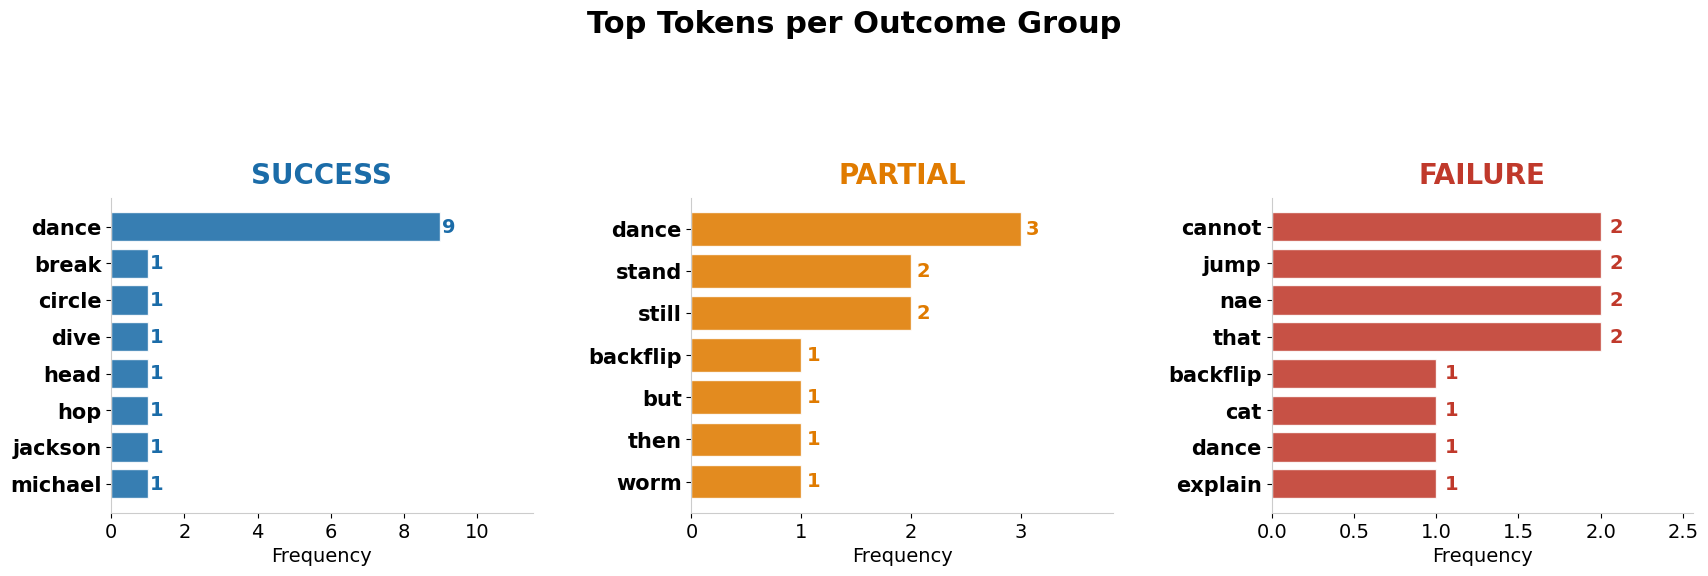

Saved plot5_token_frequency.png


In [10]:
# PLOT 5 — Top Tokens by Outcome
STOP = {'you','can','i','a','the','do','your','its','in','of','and','to',
        'is','it','not','like','me','my','be','sure','will','asked'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
fig.suptitle('Top Tokens per Outcome Group', fontsize=22, fontweight='bold', y=1.02)

for ax, outcome in zip(axes, ['success', 'partial', 'failure']):
    subset = df[df['outcome'] == outcome]['prompt'].tolist()
    cv     = CountVectorizer(stop_words=list(STOP))
    X      = cv.fit_transform(subset)
    freq   = dict(zip(cv.get_feature_names_out(), X.toarray().sum(axis=0)))
    top    = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:8]
    words, cnts = zip(*top) if top else ([], [])

    bars = ax.barh(range(len(words)), list(cnts), color=C[outcome],
                   edgecolor='white', linewidth=1, alpha=0.88)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=15, fontweight='bold')
    ax.invert_yaxis()
    for bar, cnt in zip(bars, cnts):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(int(cnt)), va='center', fontsize=14, fontweight='bold', color=C[outcome])
    ax.set_title(outcome.upper(), fontsize=20, fontweight='bold', color=C[outcome], pad=10)
    ax.set_xlabel('Frequency', fontsize=14)
    ax.set_xlim(0, max(cnts) * 1.28 if cnts else 1)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    for sp in ['left','bottom']: ax.spines[sp].set_color('#CCCCCC')

plt.tight_layout(pad=2.5)
plt.savefig('plots/plot5_token_frequency.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot5_token_frequency.png")


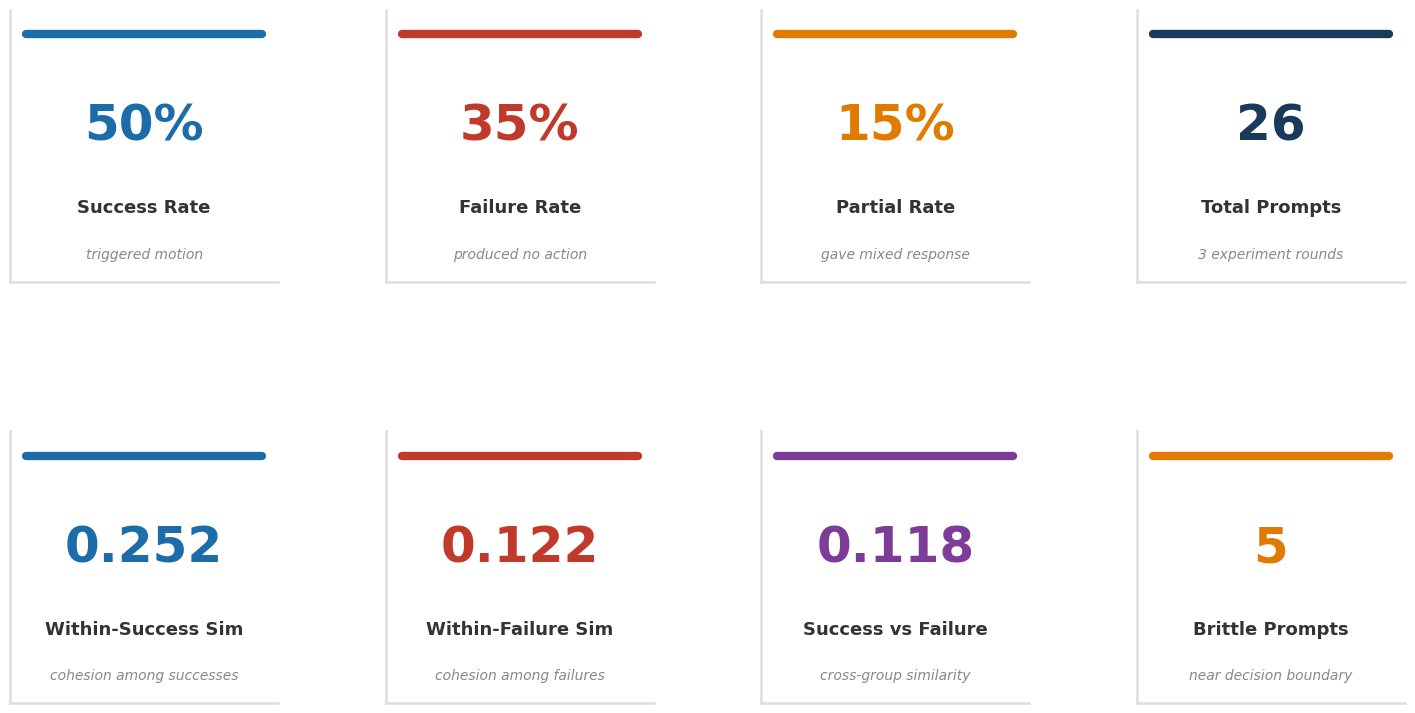

Saved plot6_kpi_dashboard.png


In [13]:
# PLOT 6 — KPI Summary Dashboard
success_rate = (df['outcome']=='success').mean() * 100
failure_rate = (df['outcome']=='failure').mean() * 100
partial_rate = (df['outcome']=='partial').mean() * 100

within_s = np.mean([sim_matrix[i,j]
                    for i in df[df['outcome']=='success']['prompt_id']
                    for j in df[df['outcome']=='success']['prompt_id'] if i!=j])
within_f = np.mean([sim_matrix[i,j]
                    for i in df[df['outcome']=='failure']['prompt_id']
                    for j in df[df['outcome']=='failure']['prompt_id'] if i!=j])
cross_sf = np.mean([sim_matrix[i,j]
                    for i in df[df['outcome']=='success']['prompt_id']
                    for j in df[df['outcome']=='failure']['prompt_id']])
brittle_n = int(((df['outcome']=='failure') & (df['delta'].abs() < 0.05)).sum())

kpis = [
    ('Success Rate',         f'{success_rate:.0f}%',   C['success'],  'triggered motion'),
    ('Failure Rate',         f'{failure_rate:.0f}%',   C['failure'],  'produced no action'),
    ('Partial Rate',         f'{partial_rate:.0f}%',   C['partial'],  'gave mixed response'),
    ('Total Prompts',        f'{len(df)}',              '#1A3A5C',     '3 experiment rounds'),
    ('Within-Success Sim',   f'{within_s:.3f}',         C['success'],  'cohesion among successes'),
    ('Within-Failure Sim',   f'{within_f:.3f}',         C['failure'],  'cohesion among failures'),
    ('Success vs Failure',   f'{cross_sf:.3f}',         '#7D3C98',     'cross-group similarity'),
    ('Brittle Prompts',      f'{brittle_n}',            '#E07B00',     'near decision boundary'),
]

fig = plt.figure(figsize=(18, 9), facecolor='white')
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.40)

for idx, (title, value, color, subtitle) in enumerate(kpis):
    row, col = divmod(idx, 4)
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_color('#DDDDDD')
        spine.set_linewidth(1.8)
    ax.plot([0.06, 0.94], [0.91, 0.91], color=color, linewidth=6,
            solid_capstyle='round', transform=ax.transAxes, clip_on=False)
    ax.text(0.5, 0.57, value,
            ha='center', va='center', fontsize=36, fontweight='black',
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.27, title,
            ha='center', va='center', fontsize=13, fontweight='bold',
            color='#333333', transform=ax.transAxes)
    ax.text(0.5, 0.10, subtitle,
            ha='center', va='center', fontsize=10, color='#888888',
            transform=ax.transAxes, style='italic')
    ax.set_xticks([]); ax.set_yticks([])

#fig.suptitle('Reachy Mini  |  Experiment KPI Summary',
 #            fontsize=24, fontweight='bold', y=1.02, color='#1A1A2E')

plt.savefig('plots/plot6_kpi_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved plot6_kpi_dashboard.png")
